In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/Fact_Sales.csv")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,1/4/2023,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,8/23/2024,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2/27/2024,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,10/15/2023,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,5/8/2025,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,6/20/2024,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,3/4/2024,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,No Coupon,Facebook,1325.06
1197,ORD201197,7/13/2023,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,8/22/2024,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


#Data check


Convert the date to the correct Datetime format

In [7]:
df['Date'] = pd.to_datetime(df['Date'])


Checking for missing and duplicate values

In [13]:
missing_values = df.isnull().sum()
missing_values

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [14]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

#(Descriptive Statistics)

In [15]:
descriptive_stats = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()
print(descriptive_stats)

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


#Deep-Dive Analysis

Product analysis

In [19]:
product_analysis = df.groupby('Product').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('TotalPrice', 'sum'),
    Average_Unit_Price=('UnitPrice', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

print(product_analysis)

         Total_Quantity  Total_Revenue  Average_Unit_Price
Product                                                   
Chair               562      195620.11          355.660281
Printer             542      195612.61          351.714917
Laptop              535      192126.56          357.707052
Tablet              497      186568.95          367.679106
Monitor             480      175651.41          358.663620
Desk                508      167459.93          329.608118
Phone               411      151722.39          375.217564


OrderStatus

In [20]:
order_status_analysis = df['OrderStatus'].value_counts(normalize=True) * 100
print(order_status_analysis)

OrderStatus
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64


#Time-Series Analysis

Monthly sales compilation to identify time patterns

In [26]:
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
print(monthly_sales)

   YearMonth  TotalPrice
0    2023-01    56685.75
1    2023-02    40117.66
2    2023-03    48609.37
3    2023-04    27751.71
4    2023-05    63836.84
5    2023-06    49500.19
6    2023-07    42820.66
7    2023-08    54352.14
8    2023-09    29526.67
9    2023-10    52607.85
10   2023-11    43079.67
11   2023-12    43754.73
12   2024-01    38528.08
13   2024-02    36909.57
14   2024-03    36030.90
15   2024-04    49613.14
16   2024-05    27909.11
17   2024-06    68068.54
18   2024-07    42963.98
19   2024-08    31991.07
20   2024-09    39794.98
21   2024-10    37226.97
22   2024-11    32413.76
23   2024-12    38785.77
24   2025-01    29099.40
25   2025-02    35317.55
26   2025-03    39200.66
27   2025-04    31821.20
28   2025-05    43396.64
29   2025-06    53047.40


In [28]:
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
monthly_sales

,YearMonth,TotalPrice
0,2023-01,56685.75
1,2023-02,40117.66
2,2023-03,48609.37
3,2023-04,27751.71
4,2023-05,63836.84
5,2023-06,49500.19
6,2023-07,42820.66
7,2023-08,54352.14
8,2023-09,29526.67
9,2023-10,52607.85


In [30]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

/tmp/ipykernel_2630/150141123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_revenue, x='TotalPrice', y='Product', palette='Blues_r')


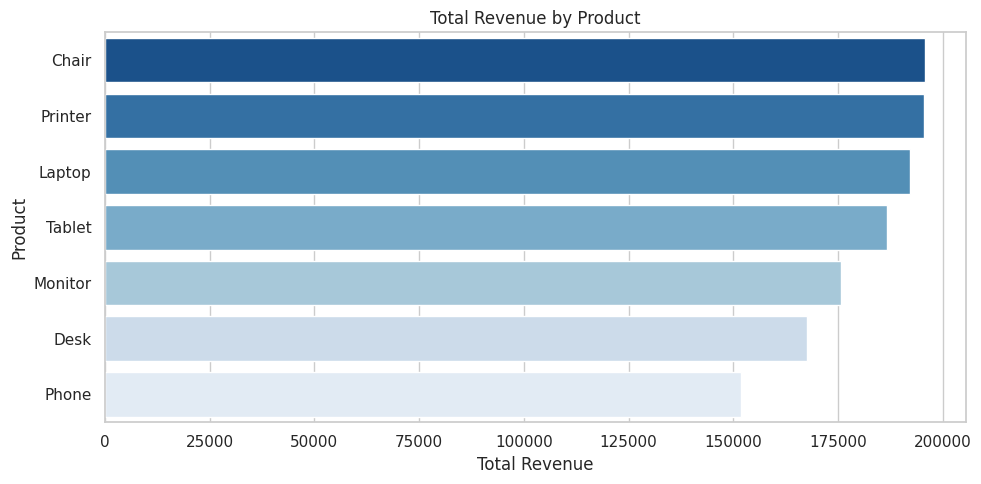

In [38]:
plt.figure(figsize=(10, 5))
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=product_revenue, x='TotalPrice', y='Product', palette='Blues_r')
plt.title('Total Revenue by Product')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()

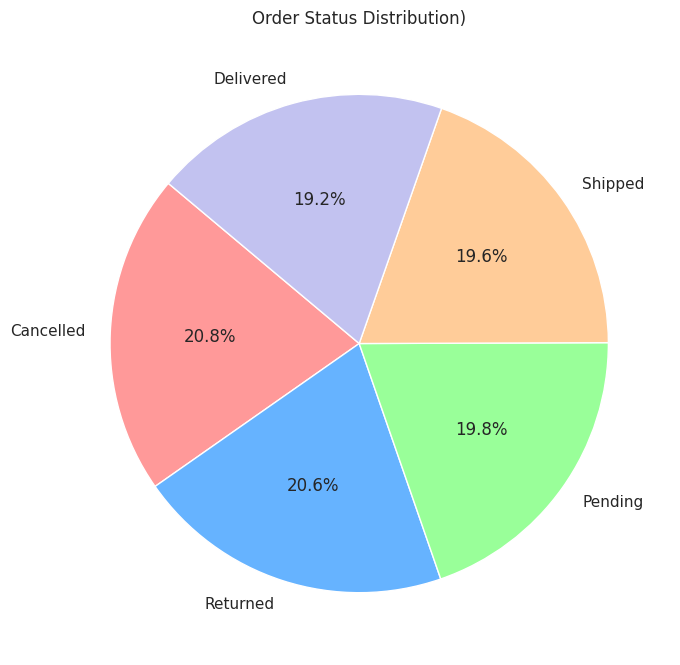

In [39]:
plt.figure(figsize=(7, 7))
order_status_counts = df['OrderStatus'].value_counts()
plt.pie(order_status_counts, labels=order_status_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.title('Order Status Distribution)')
plt.tight_layout()
